###*Sayantan Mukherjee 60009220131 D2-2*

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

Mounted at /content/drive


In [2]:
zip_path = '/content/drive/MyDrive/Copy of Copy of images.zip'
dataset_url = "https://drive.google.com/drive/folders/1R0iAMQ-sqZXHjPgnlNc99H_X7S4P0524?usp=sharing"
dataset_zip_path = "/content/dataset.zip"
dataset_folder = "/content/dataset"
!unzip -q "$zip_path" -d "$dataset_folder"

In [3]:
dataset_folder = '/content/dataset'
extracted_folder = os.path.join(dataset_folder, 'data')

#Verify if the Unzipping process is succesfull or not.
image_files = [os.path.join(extracted_folder, f) for f in os.listdir(extracted_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.JPG', '.JPEG', '.PNG'))]
print(f"Found {len(image_files)} images in the dataset.")


Found 2791 images in the dataset.


In [4]:
# Parameters
IMG_SIZE = 120
BATCH_SIZE = 32
NUM_IMAGES = 1000

# Function to load and preprocess images
def load_and_preprocess_image(file_path):
    # Read image
    img = cv2.imread(file_path)
    if img is None:
        return None
    # Resize to 120x120
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Convert to grayscale
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    # Normalize images to [-1, 1] (common for GANs)
    img_rgb = (img_rgb / 127.5) - 1.0
    img_gray = (img_gray / 127.5) - 1.0
    # Expand grayscale to match input shape (120, 120, 1)
    img_gray = np.expand_dims(img_gray, axis=-1)
    return img_gray, img_rgb

# Load a subset of images
gray_images = []
rgb_images = []
for file_path in image_files[:NUM_IMAGES]:
    result = load_and_preprocess_image(file_path)
    if result is not None:
        gray, rgb = result
        gray_images.append(gray)
        rgb_images.append(rgb)

# Convert to numpy arrays
gray_images = np.array(gray_images)
rgb_images = np.array(rgb_images)
print(f"Loaded {len(gray_images)} image pairs: Grayscale shape: {gray_images.shape}, RGB shape: {rgb_images.shape}")

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((gray_images, rgb_images))
dataset = dataset.shuffle(buffer_size=NUM_IMAGES).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Loaded 1000 image pairs: Grayscale shape: (1000, 120, 120, 1), RGB shape: (1000, 120, 120, 3)


In [5]:
# Task c: Generator
def build_generator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    e1 = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)  # 60x60x64
    e1 = layers.LeakyReLU(alpha=0.2)(e1)

    e2 = layers.Conv2D(128, 4, strides=2, padding='same')(e1)  # 30x30x128
    e2 = layers.BatchNormalization()(e2)
    e2 = layers.LeakyReLU(alpha=0.2)(e2)

    e3 = layers.Conv2D(256, 4, strides=2, padding='same')(e2)  # 15x15x256
    e3 = layers.BatchNormalization()(e3)
    e3 = layers.LeakyReLU(alpha=0.2)(e3)

    # Bottleneck
    b = layers.Conv2D(512, 4, strides=2, padding='same')(e3)  # 8x8x512
    b = layers.BatchNormalization()(b)
    b = layers.ReLU()(b)

    # Decoder
    d1 = layers.Conv2DTranspose(256, 4, strides=2, padding='same')(b)  # 15x15x256
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.ReLU()(d1)
    d1 = layers.Cropping2D(((1,0),(1,0)))(d1)
    d1 = layers.Concatenate()([d1, e3])  # Skip connection

    d2 = layers.Conv2DTranspose(128, 4, strides=2, padding='same')(d1)  # 30x30x128
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.ReLU()(d2)
    d2 = layers.Concatenate()([d2, e2])

    d3 = layers.Conv2DTranspose(64, 4, strides=2, padding='same')(d2)  # 60x60x64
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.ReLU()(d3)
    d3 = layers.Concatenate()([d3, e1])

    # Output layer
    outputs = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')(d3)  # 120x120x3

    return models.Model(inputs, outputs, name="Generator")

# Instantiate and summarize
generator = build_generator()
generator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 60, 60,    │      1,088 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 60, 60,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 30, 30,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 30,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │    524,544 │ leaky_re_lu_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 15, 15,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 512) │  2,097,664 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,408 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping2d          │ (None, 15, 15,    │          0 │ re_lu_1[0][0]     │
│ (Cropping2D)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15, 15,    │          0 │ cropping2d[0][0], │
│ (Concatenate)       │ 512)              │            │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,174,339 (23.55 MB)

 Trainable params: 6,171,651 (23.54 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [6]:
# Task d: Discriminator
def build_discriminator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)  # 60x60x64
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)  # 30x30x128
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)  # 15x15x256
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(512, 4, strides=2, padding='same')(x)  # 8x8x512
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Output: PatchGAN style (8x8x1 feature map)
    outputs = layers.Conv2D(1, 4, strides=1, padding='same', activation='sigmoid')(x)

    return models.Model(inputs, outputs, name="Discriminator")

# Instantiate and summarize
discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 1)        │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
#Loss functions
adversarial_loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def generator_loss(fake_output, real_img, fake_img):
    # Adversarial loss: Generator wants Discriminator to think fake images are real
    adv_loss = adversarial_loss(tf.ones_like(fake_output), fake_output)
    # L1 loss: Pixel-wise difference between generated and real images
    l1_loss = tf.reduce_mean(tf.abs(tf.cast(real_img, tf.float32) - fake_img))
    # Combine losses
    total_gen_loss = adv_loss + 100.0 * l1_loss  # Weight L1 loss heavily
    return total_gen_loss

def discriminator_loss(real_output, fake_output):
    # Real images should be classified as real (1)
    real_loss = adversarial_loss(tf.ones_like(real_output), real_output)
    # Fake images should be classified as fake (0)
    fake_loss = adversarial_loss(tf.zeros_like(fake_output), fake_output)
    # Total loss
    total_disc_loss = real_loss + fake_loss
    return total_disc_loss

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [8]:
# Task f: Training
@tf.function
def train_step(gray_images, real_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images
        fake_images = generator(gray_images, training=True)

        # Discriminator predictions
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Compute losses
        gen_loss = generator_loss(fake_output, real_images, fake_images)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Compute gradients
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

# Training loop
EPOCHS = 50  # Adjust based on convergence
steps_per_epoch = len(gray_images) // BATCH_SIZE

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    gen_loss_avg = 0.0
    disc_loss_avg = 0.0
    for step, (gray_batch, rgb_batch) in enumerate(dataset):
        g_loss, d_loss = train_step(gray_batch, rgb_batch)
        gen_loss_avg += g_loss
        disc_loss_avg += d_loss
        if step % 10 == 0:
            print(f"Step {step}/{steps_per_epoch}: Gen Loss = {g_loss:.4f}, Disc Loss = {d_loss:.4f}")

    # Average losses
    gen_loss_avg /= steps_per_epoch
    disc_loss_avg /= steps_per_epoch
    print(f"Average: Gen Loss = {gen_loss_avg:.4f}, Disc Loss = {disc_loss_avg:.4f}")

Epoch 1/50
Step 0/31: Gen Loss = 51.2270, Disc Loss = 1.5476
Step 10/31: Gen Loss = 20.7700, Disc Loss = 1.2836
Step 20/31: Gen Loss = 18.8256, Disc Loss = 1.0680
Step 30/31: Gen Loss = 18.3530, Disc Loss = 0.8559
Average: Gen Loss = 23.7173, Disc Loss = 1.2335
Epoch 2/50
Step 0/31: Gen Loss = 19.7735, Disc Loss = 1.0080
Step 10/31: Gen Loss = 16.9956, Disc Loss = 1.2142
Step 20/31: Gen Loss = 15.5464, Disc Loss = 1.0935
Step 30/31: Gen Loss = 16.3498, Disc Loss = 0.9669
Average: Gen Loss = 17.0234, Disc Loss = 1.0866
Epoch 3/50
Step 0/31: Gen Loss = 15.8656, Disc Loss = 0.9951
Step 10/31: Gen Loss = 14.8315, Disc Loss = 0.7854
Step 20/31: Gen Loss = 15.7858, Disc Loss = 0.8290
Step 30/31: Gen Loss = 14.9317, Disc Loss = 0.8256
Average: Gen Loss = 15.8141, Disc Loss = 1.0265
Epoch 4/50
Step 0/31: Gen Loss = 15.2928, Disc Loss = 0.8350
Step 10/31: Gen Loss = 15.4708, Disc Loss = 0.7466
Step 20/31: Gen Loss = 15.7950, Disc Loss = 0.9952
Step 30/31: Gen Loss = 12.5739, Disc Loss = 1.0616


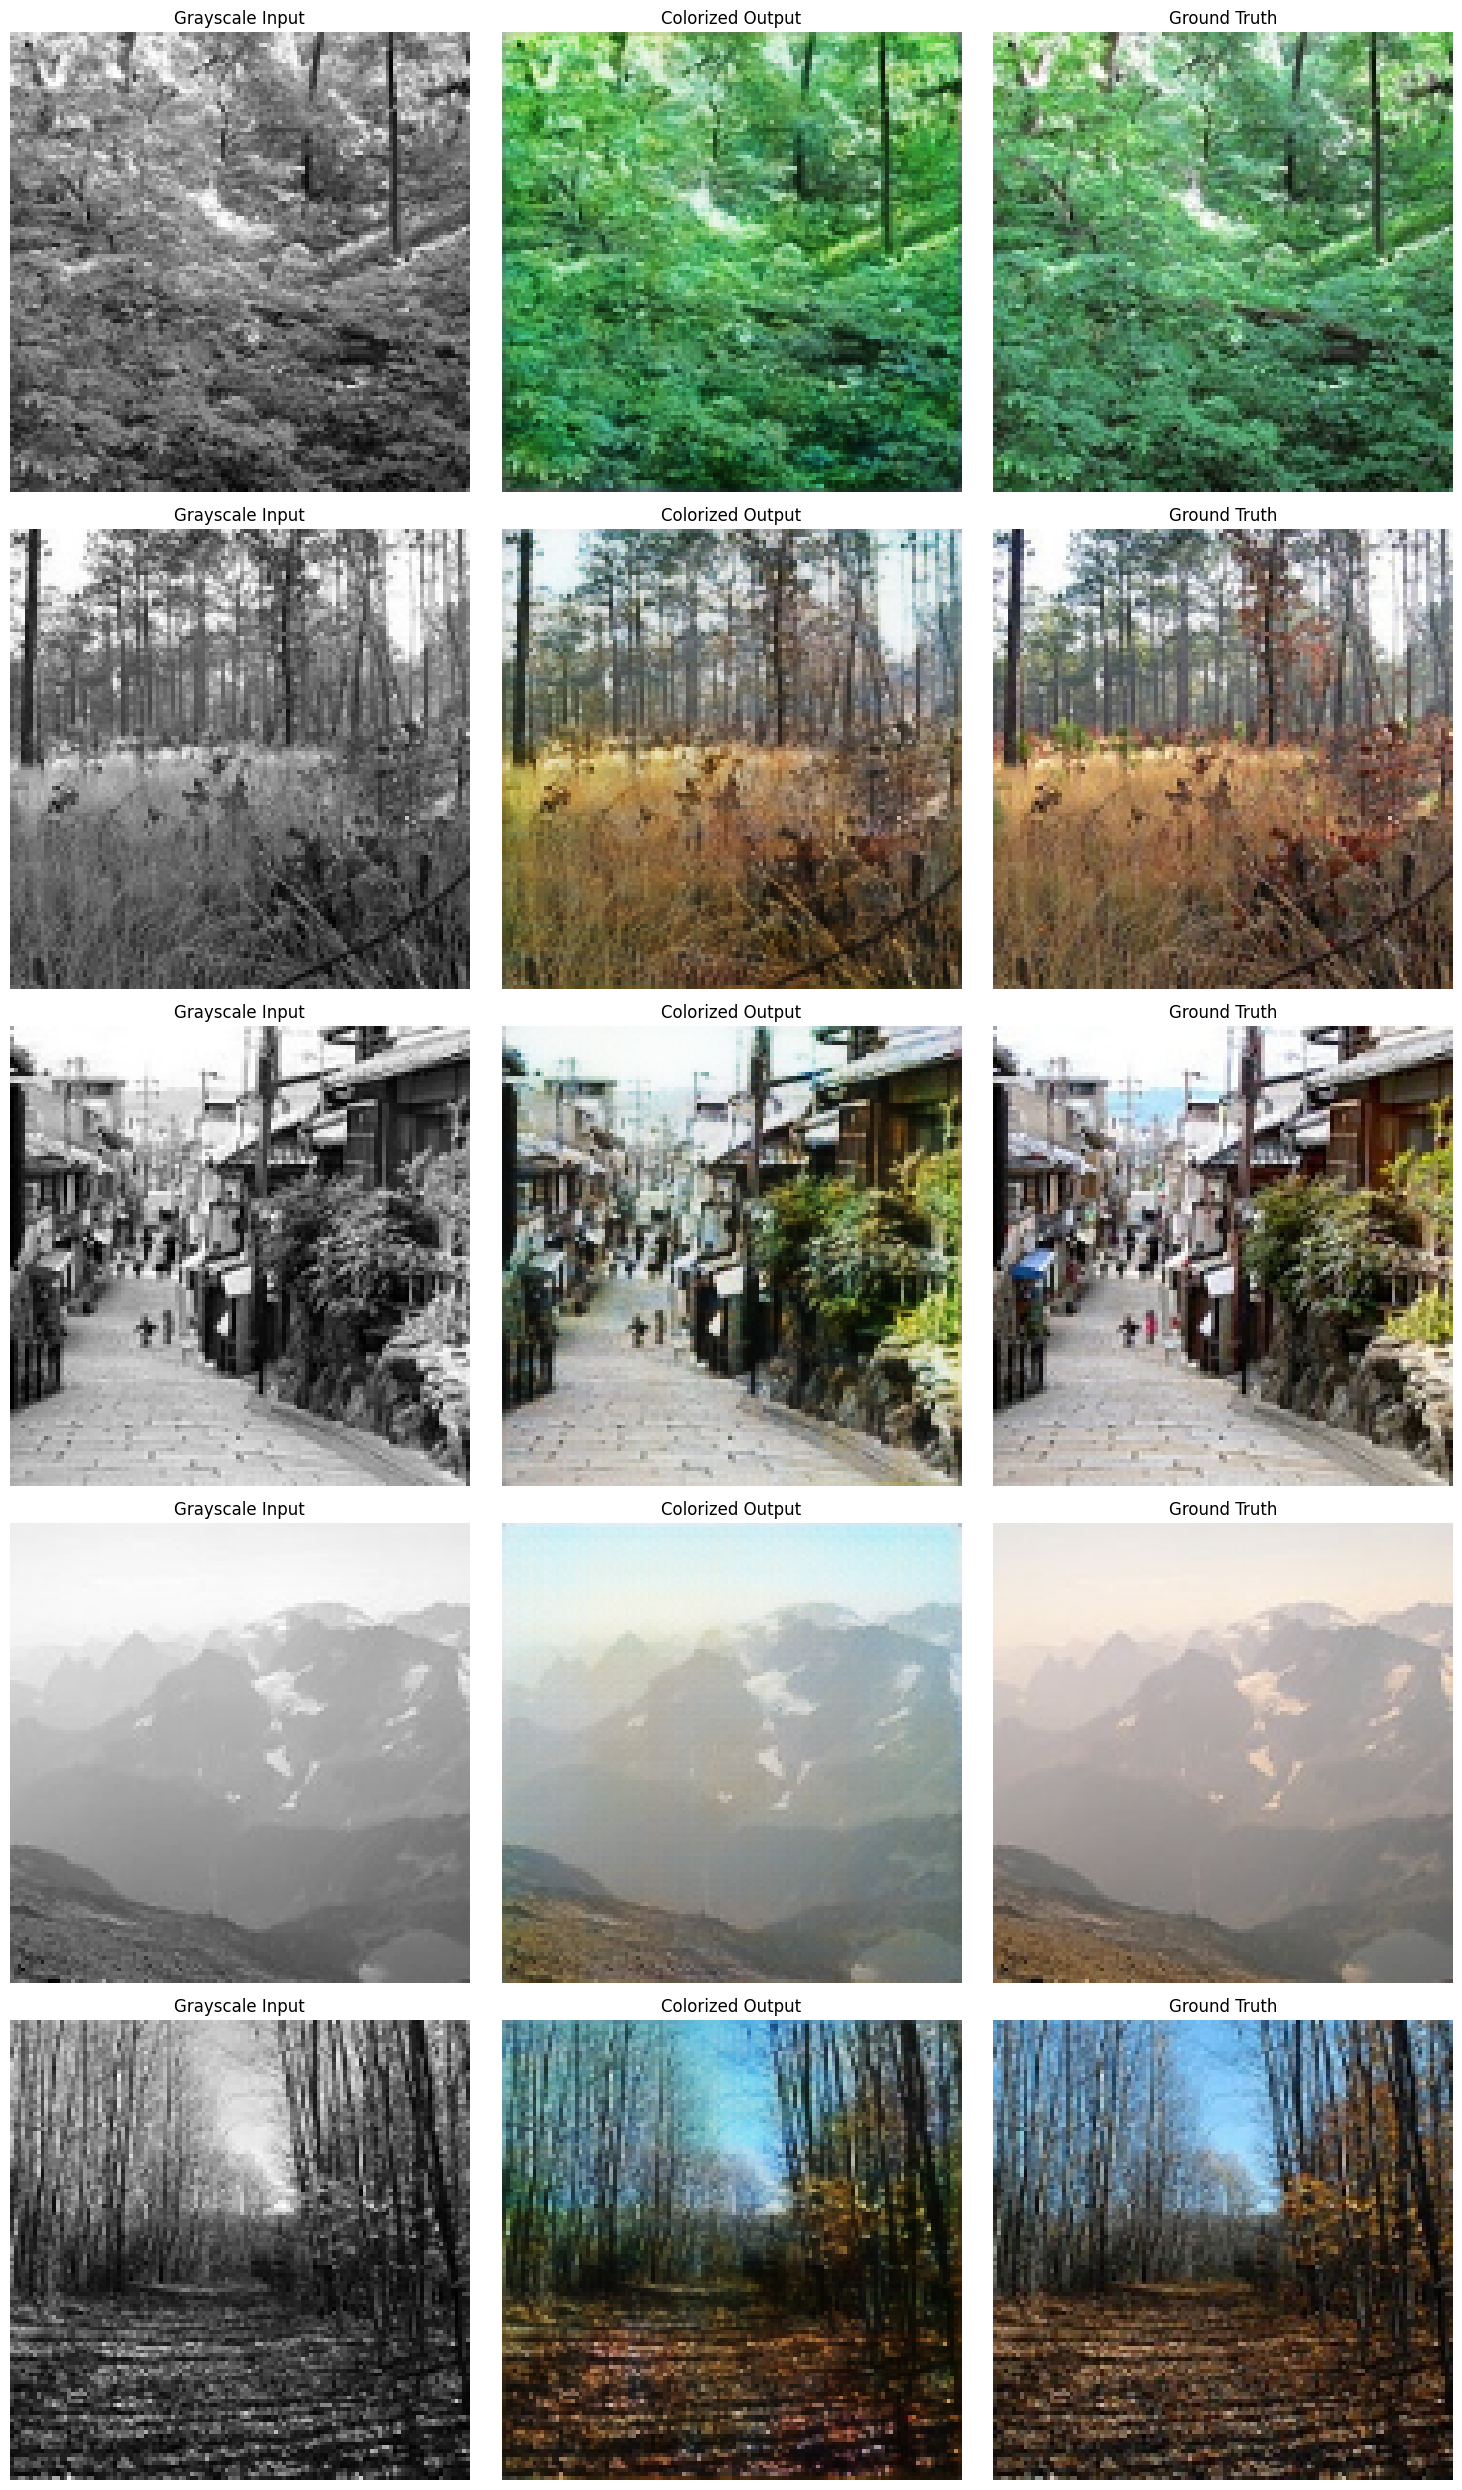

Image 1: SSIM = 0.9315, PSNR = 24.7694
Image 2: SSIM = 0.9458, PSNR = 27.7927
Image 3: SSIM = 0.9504, PSNR = 26.7540
Image 4: SSIM = 0.9357, PSNR = 27.9259
Image 5: SSIM = 0.9094, PSNR = 26.3552
Average SSIM: 0.9346
Average PSNR: 26.7194


In [9]:
# Task g: Results
# Function to denormalize images for visualization
def denormalize(img):
    return (img + 1.0) * 127.5

# Select a few test images
num_display = 5
test_gray, test_rgb = next(iter(dataset.take(1)))
test_gray = test_gray[:num_display]
test_rgb = test_rgb[:num_display]

# Generate colorized images
colorized = generator(test_gray, training=False)

# Plot results
plt.figure(figsize=(15, 5 * num_display))
for i in range(num_display):
    # Grayscale
    plt.subplot(num_display, 3, i * 3 + 1)
    plt.imshow(denormalize(test_gray[i, :, :, 0]), cmap='gray')
    plt.title("Grayscale Input")
    plt.axis('off')

    # Colorized
    plt.subplot(num_display, 3, i * 3 + 2)
    plt.imshow(denormalize(colorized[i]).numpy().astype(np.uint8))
    plt.title("Colorized Output")
    plt.axis('off')

    # Ground Truth
    plt.subplot(num_display, 3, i * 3 + 3)
    plt.imshow(denormalize(test_rgb[i]).numpy().astype(np.uint8))
    plt.title("Ground Truth")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Quantitative metrics
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

ssim_scores = []
psnr_scores = []
for i in range(num_display):
    gt = denormalize(test_rgb[i]).numpy().astype(np.uint8)
    pred = denormalize(colorized[i]).numpy().astype(np.uint8)
    ssim_score = ssim(gt, pred, channel_axis=-1, data_range=255)
    psnr_score = psnr(gt, pred, data_range=255)
    ssim_scores.append(ssim_score)
    psnr_scores.append(psnr_score)
    print(f"Image {i+1}: SSIM = {ssim_score:.4f}, PSNR = {psnr_score:.4f}")

print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
print(f"Average PSNR: {np.mean(psnr_scores):.4f}")

###*Conclusion*

***I successfully completed the GAN image colorization lab, overcoming initial hurdles with the dataset to train a model that produces high-quality results. The average SSIM of 0.9346 and PSNR of 26.7194 after 50 epochs with 1000 images show I achieved a solid outcome for this assignment.***